# Cleaned Dataset — Exploratory Analysis

This notebook inspects `data/cleaned.csv` to surface missing data, outliers,
suspicious default values, and other things worth cleaning before analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('data/cleaned.csv')
df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 1,392 rows × 53 columns


,ncei_id,location_name,ncei_magnitude,damage_order,mag_body_wave,published,damage_order_total,houses_damaged_total,houses_damaged_order_total,country,region_code,injuries,injuries_order,houses_destroyed,houses_destroyed_order,houses_damaged,houses_damaged_order,mag_moment,mag_surface_wave,injuries_total,injuries_order_total,houses_destroyed_total,houses_destroyed_order_total,deaths,deaths_order,damage_millions,mag_local,deaths_total,deaths_order_total,damage_millions_total,tsunami_event_id,intensity,volcano_event_id,area,missing,missing_order,missing_total,missing_order_total,mag_unkown,usgs_id,time,latitude,longitude,depth,usgs_magnitude,place,sig,mmi,alert,magnitude,year,depth_category,region
0,5551,INDIA-BANGLADESH BORDER: MAHESHKHALI,4.60,1.00,4.60,True,1.00,100.00,2.00,INDIA,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usp0009kqm,2000-01-03 22:34:12.640000+00:00,22.13,92.77,33.00,4.60,"45 km SSW of Saiha, India",326,3.70,NaN,4.60,2000,shallow,INDIA-BANGLADESH BORDER: MAHESHKHALI
1,5552,CHINA: LIAONING PROVINCE,5.10,3.00,4.90,True,3.00,8800.00,4.00,CHINA,30,30.00,1.00,3600.00,4.00,8800.00,4.00,5.10,4.70,30.00,1.00,3600.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usp0009m1j,2000-01-11 23:43:56.450000+00:00,40.50,122.99,10.00,5.10,"Liaoning, China",400,4.60,NaN,5.10,2000,shallow,CHINA: LIAONING PROVINCE
2,5553,CHINA: YUNNAN PROVINCE: YAOAN COUNTY,5.90,4.00,5.40,True,4.00,NaN,NaN,CHINA,30,2528.00,4.00,41000.00,4.00,NaN,NaN,5.90,5.90,2528.00,4.00,41000.00,4.00,5.00,1.00,73.50,5.50,7.00,1.00,73.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usp0009m4u,2000-01-14 23:37:07.870000+00:00,25.61,101.06,33.00,5.90,"85 km E of Dali, China",536,5.93,NaN,5.90,2000,shallow,CHINA: YUNNAN PROVINCE: YAOAN COUNTY


## 1. Column overview — dtypes and non-null counts

In [4]:
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notna().sum(),
    'null':     df.isna().sum(),
    'pct_null': (df.isna().mean() * 100).round(1),
    'n_unique': df.nunique(),
})
info.sort_values('pct_null', ascending=False)

,dtype,non_null,null,pct_null,n_unique
mag_unkown,float64,2,1390,99.90,2
volcano_event_id,float64,13,1379,99.10,13
missing_order,float64,18,1374,98.70,3
missing,float64,19,1373,98.60,15
missing_total,float64,19,1373,98.60,15
missing_order_total,float64,21,1371,98.50,3
area,str,73,1319,94.80,22
mag_local,float64,112,1280,92.00,41
damage_millions,float64,250,1142,82.00,168
damage_millions_total,float64,257,1135,81.50,170


## 2. Missing data heatmap

White = missing. Columns sorted by % missing.

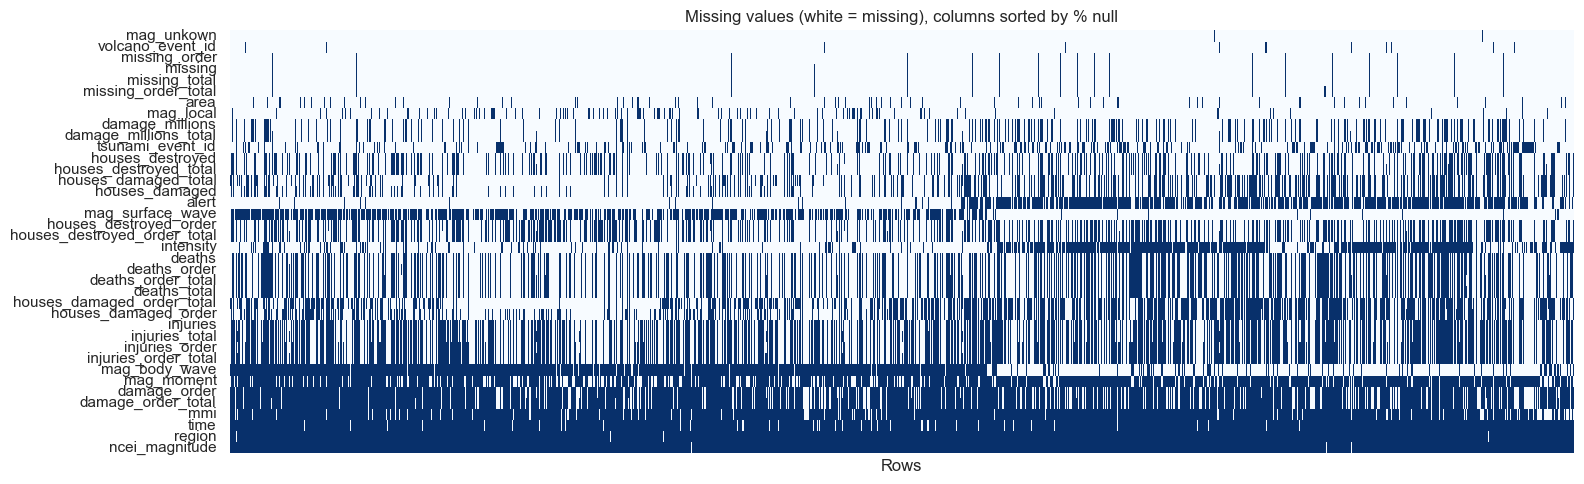

In [5]:
missing_order = df.isna().mean().sort_values(ascending=False)
mostly_missing = missing_order[missing_order > 0].index.tolist()

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    df[mostly_missing].isna().T,
    cbar=False, yticklabels=True, xticklabels=False,
    cmap='Blues_r', ax=ax
)
ax.set_title('Missing values (white = missing), columns sorted by % null')
ax.set_xlabel('Rows')
plt.tight_layout()
plt.show()

## 3. Missing data — bar chart of % null per column

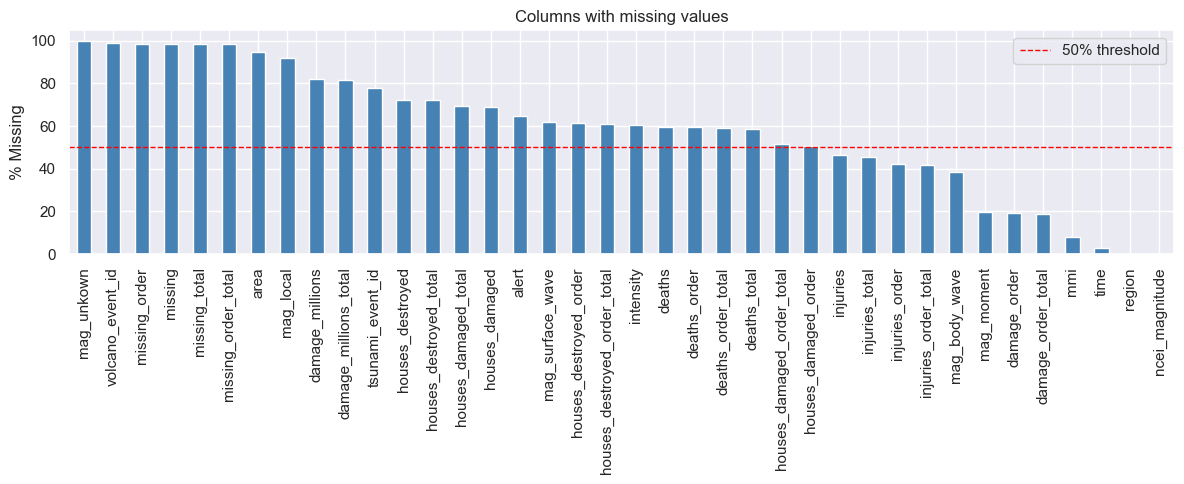


Columns >50% missing (candidates to drop):
mag_unkown                     99.86
volcano_event_id               99.07
missing_order                  98.71
missing                        98.64
missing_total                  98.64
missing_order_total            98.49
area                           94.76
mag_local                      91.95
damage_millions                82.04
damage_millions_total          81.54
tsunami_event_id               77.73
houses_destroyed               72.41
houses_destroyed_total         72.05
houses_damaged_total           69.25
houses_damaged                 68.82
alert                          64.80
mag_surface_wave               61.78
houses_destroyed_order         61.42
houses_destroyed_order_total   61.14
intensity                      60.63
deaths                         59.70
deaths_order                   59.55
deaths_order_total             58.91
deaths_total                   58.84
houses_damaged_order_total     51.51
houses_damaged_order           

In [6]:
pct_null = df.isna().mean().sort_values(ascending=False) * 100
pct_null = pct_null[pct_null > 0]

fig, ax = plt.subplots(figsize=(12, 5))
pct_null.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_ylabel('% Missing')
ax.set_title('Columns with missing values')
ax.legend()
plt.tight_layout()
plt.show()

print('\nColumns >50% missing (candidates to drop):')
print(pct_null[pct_null > 50].to_string())

## 4. Numeric distributions — key physics & impact columns

In [7]:
num_cols = ['magnitude', 'depth', 'deaths', 'injuries', 'damage_millions',
            'houses_destroyed', 'houses_damaged', 'sig', 'mmi']
num_cols = [c for c in num_cols if c in df.columns]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
magnitude,1392.00,5.97,1.05,0.00,5.20,5.90,6.70,9.10
depth,1392.00,30.20,60.21,-2.50,10.00,14.25,32.00,675.40
deaths,561.00,1147.09,14477.05,1.00,1.00,3.00,12.00,316000.00
injuries,748.00,1661.98,16699.14,1.00,6.00,26.50,132.25,374171.00
damage_millions,250.00,1822.46,7037.54,0.30,21.85,100.00,507.25,86000.00
houses_destroyed,384.00,25869.25,278235.10,1.00,20.00,221.00,1792.00,5360000.00
houses_damaged,434.00,32028.78,271619.02,1.00,100.00,660.50,4375.00,5360000.00
sig,1392.00,710.34,405.21,0.00,442.75,630.00,848.50,2910.00
mmi,1280.00,6.15,1.31,0.00,5.30,6.31,7.00,9.54


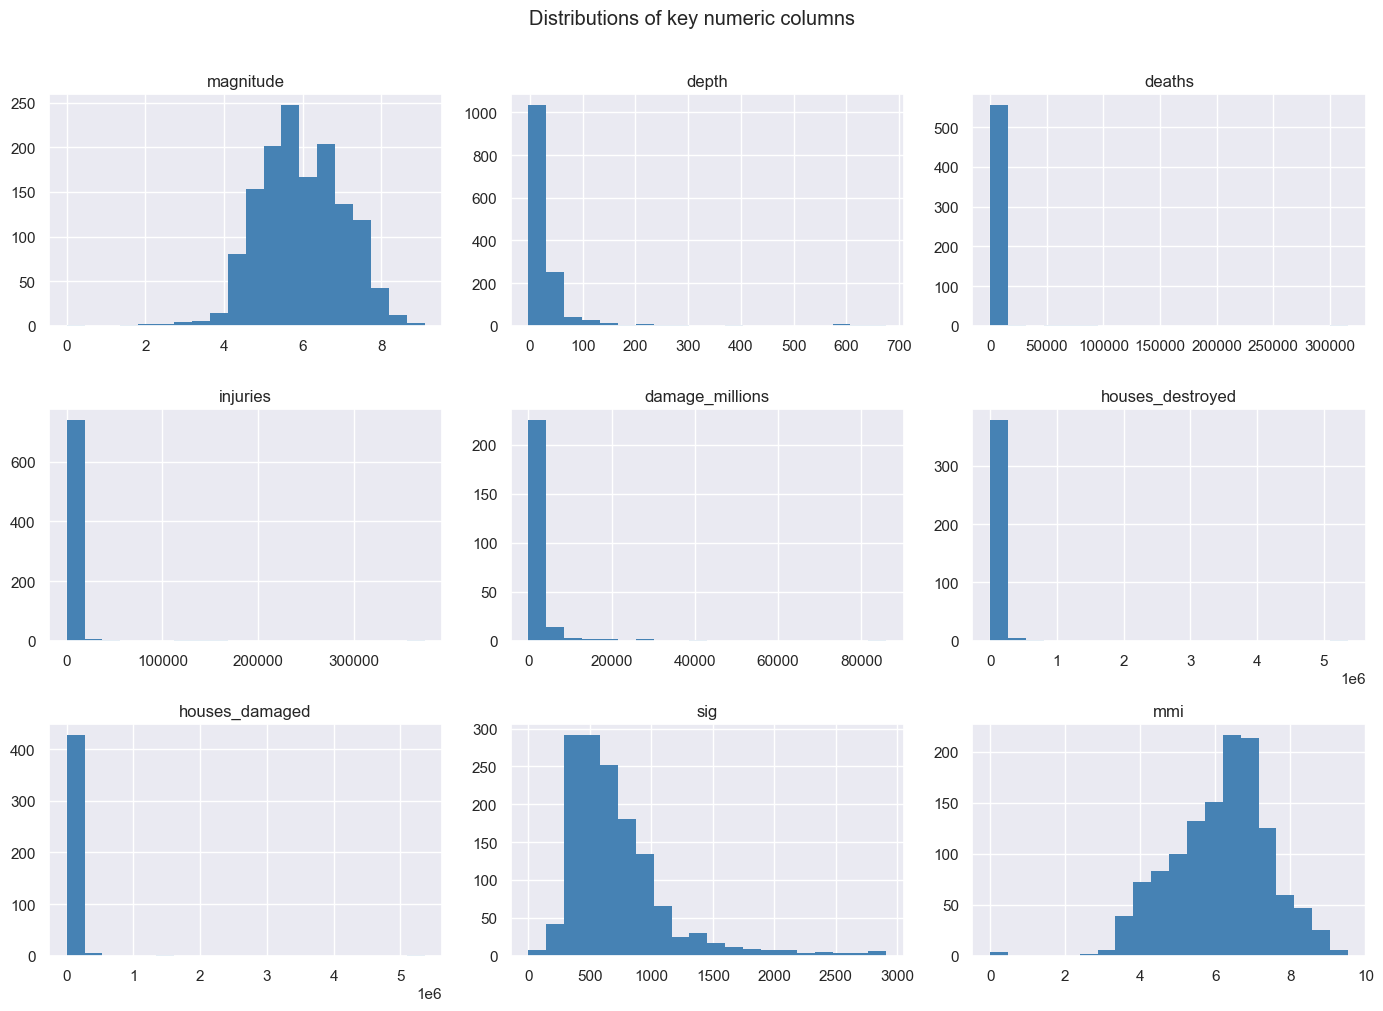

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=20, color='steelblue', edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions of key numeric columns', y=1.01)
plt.tight_layout()
plt.show()

## 5. Outlier check — box plots (log scale for skewed columns)

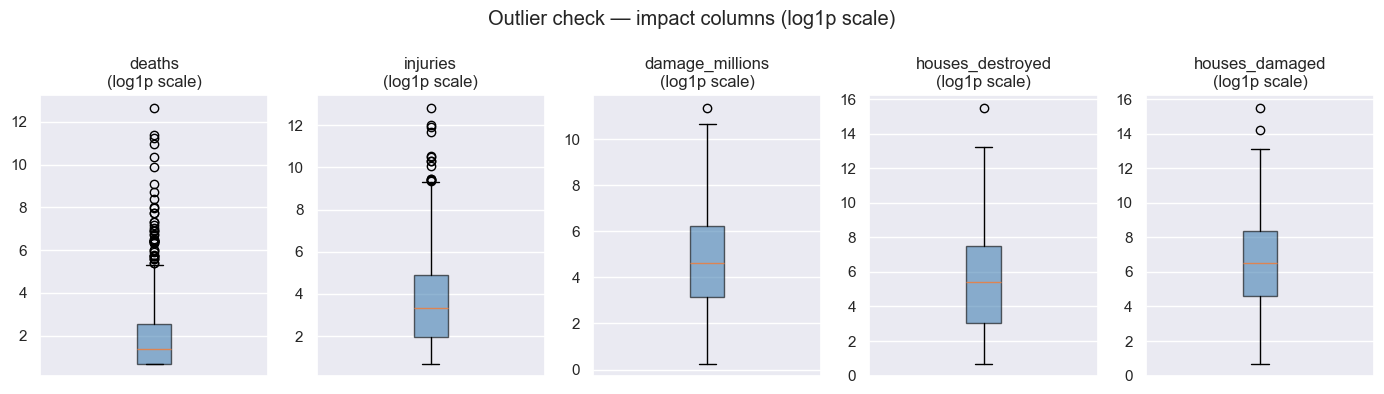


Top 10 rows by deaths:


,time,location_name,magnitude,depth,deaths,damage_millions
581,2010-01-12 21:53:10.060000+00:00,HAITI: PORT-AU-PRINCE,7.00,13.00,316000.00,8000.00
462,2008-05-12 06:28:01.570000+00:00,CHINA: SICHUAN PROVINCE,7.90,19.00,87652.00,86000.00
304,2005-10-08 03:50:40.800000+00:00,"PAKISTAN: MUZAFFARABAD, URI, ANANTNAG, BARAMULA",7.60,26.00,76213.00,6680.00
1276,2023-02-06 01:17:34.342000+00:00,TURKEY: KAHRAMANMARAS; SYRIA,7.80,10.00,56697.00,42900.00
181,2003-12-26 01:56:52.440000+00:00,"IRAN: SOUTHEASTERN: BAM, BARAVAT",6.60,10.00,31000.00,500.00
36,2001-01-26 03:16:40.500000+00:00,"INDIA: GUJARAT: BHUJ, AHMADABAD, RAJOKOT; PA...",7.70,16.00,20005.00,2623.00
860,2015-04-25 06:11:25.950000+00:00,NEPAL: KATHMANDU; INDIA; CHINA; BANGLADESH,7.80,8.22,8957.00,6000.00
341,2006-05-26 22:53:58.920000+00:00,"INDONESIA: JAVA: BANTUL, YOGYAKARTA",6.30,12.50,6234.00,3100.00
1059,2018-09-28 10:02:45.250000+00:00,INDONESIA: SULAWESI,7.50,20.00,4340.00,1500.00
600,2010-04-13 23:49:38.330000+00:00,CHINA: QINGHAI PROVINCE: YUSHU,6.90,17.00,2968.00,500.00


In [9]:
skewed = ['deaths', 'injuries', 'damage_millions', 'houses_destroyed', 'houses_damaged']
skewed = [c for c in skewed if c in df.columns]

fig, axes = plt.subplots(1, len(skewed), figsize=(14, 4))
for ax, col in zip(axes, skewed):
    data = df[col].dropna()
    data = data[data > 0]  # log scale needs positive values
    ax.boxplot(np.log1p(data), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{col}\n(log1p scale)')
    ax.set_xticks([])

fig.suptitle('Outlier check — impact columns (log1p scale)')
plt.tight_layout()
plt.show()

print('\nTop 10 rows by deaths:')
df.nlargest(10, 'deaths')[['time', 'location_name', 'magnitude', 'depth', 'deaths', 'damage_millions']]

## 6. Suspicious default values

USGS uses **depth = 10.0 km** and **depth = 33.0 km** as placeholders when depth
is unknown. These are not real measurements and may distort depth-based analysis.

In [10]:
if 'depth' in df.columns:
    default_depths = df['depth'].value_counts().head(20)
    print('Most common depth values:')
    print(default_depths.to_string())

    n_10  = (df['depth'] == 10.0).sum()
    n_33  = (df['depth'] == 33.0).sum()
    print(f'\nRows with depth=10.0 (USGS default): {n_10} ({n_10/len(df):.1%})')
    print(f'Rows with depth=33.0 (USGS default): {n_33} ({n_33/len(df):.1%})')

Most common depth values:
depth
10.00    324
33.00     51
5.00      36
12.00     34
20.00     33
11.00     28
8.00      28
16.00     23
14.00     21
35.00     20
15.00     19
18.00     17
9.00      17
13.00     16
24.00     16
19.00     16
22.00     15
17.00     13
6.00      13
30.00     12

Rows with depth=10.0 (USGS default): 324 (23.3%)
Rows with depth=33.0 (USGS default): 51 (3.7%)


## 7. Depth distribution

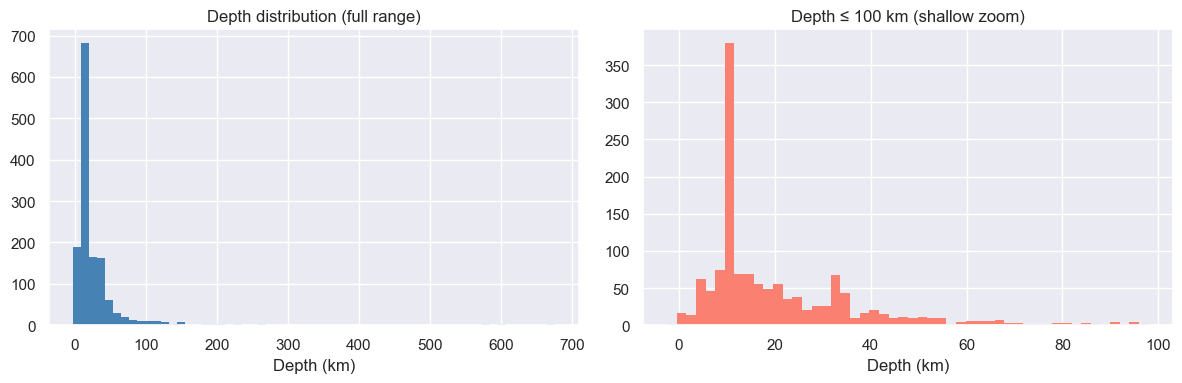


Depth category counts:
depth_category
shallow         1298
intermediate      83
deep              11


In [11]:
if 'depth' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df['depth'].dropna(), bins=60, color='steelblue', edgecolor='none')
    axes[0].set_title('Depth distribution (full range)')
    axes[0].set_xlabel('Depth (km)')

    axes[1].hist(df[df['depth'] <= 100]['depth'].dropna(), bins=50,
                 color='salmon', edgecolor='none')
    axes[1].set_title('Depth ≤ 100 km (shallow zoom)')
    axes[1].set_xlabel('Depth (km)')

    plt.tight_layout()
    plt.show()

    if 'depth_category' in df.columns:
        print('\nDepth category counts:')
        print(df['depth_category'].value_counts().to_string())

## 8. Time coverage — events per year

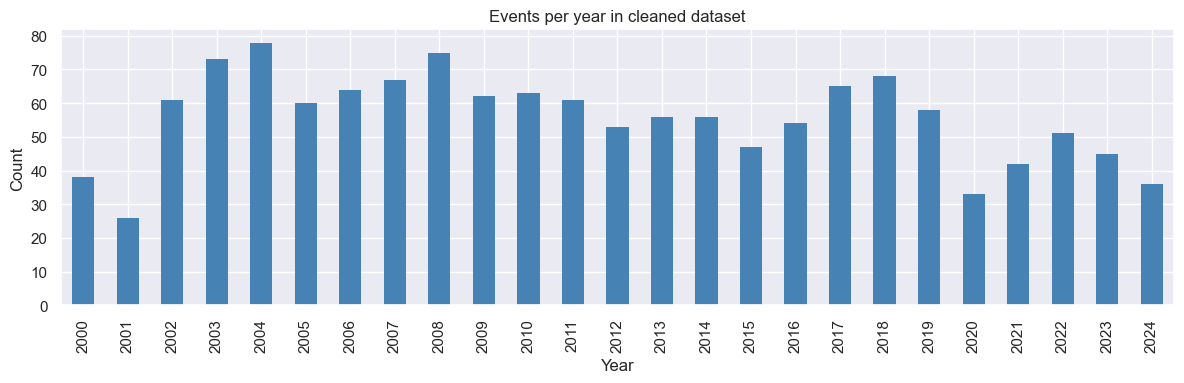

Years with unusually low counts (<10 events):
Series([], )


In [12]:
if 'year' in df.columns:
    yearly = df['year'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    yearly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
    ax.set_title('Events per year in cleaned dataset')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    print(f'Years with unusually low counts (<10 events):')
    print(yearly[yearly < 10].to_string())

## 9. Categorical columns — region, country, depth_category, alert

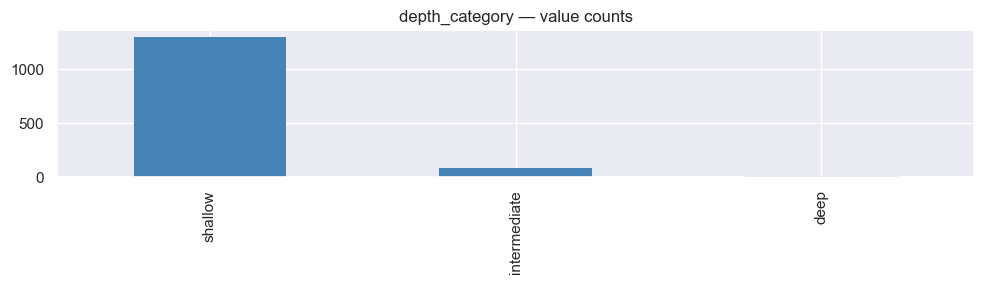

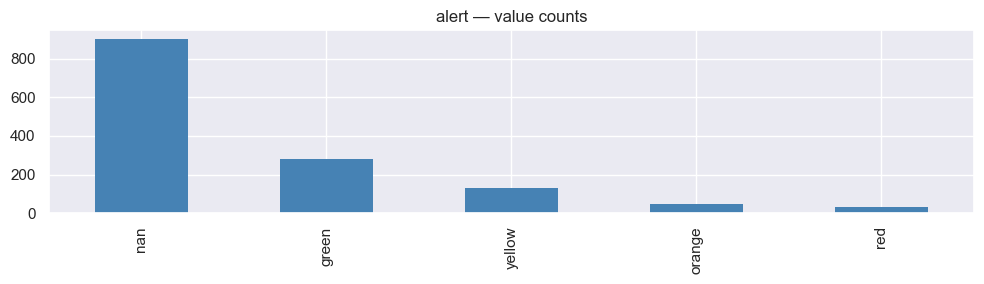

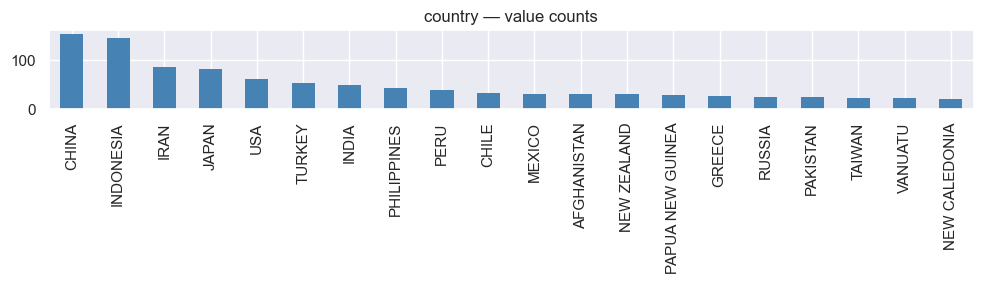

In [13]:
cat_cols = ['depth_category', 'alert', 'country']
cat_cols = [c for c in cat_cols if c in df.columns]

for col in cat_cols:
    vc = df[col].value_counts(dropna=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 3))
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(f'{col} — value counts')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

## 10. Top regions by event count

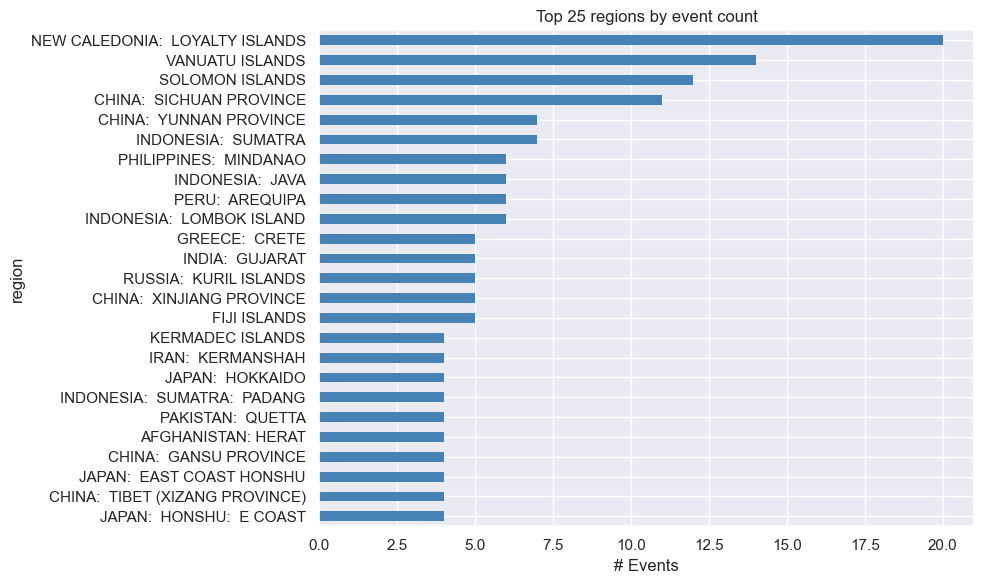

In [14]:
if 'region' in df.columns:
    top_regions = df['region'].value_counts().head(25)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_regions.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
    ax.set_title('Top 25 regions by event count')
    ax.set_xlabel('# Events')
    plt.tight_layout()
    plt.show()

## 11. Correlation heatmap — numeric columns

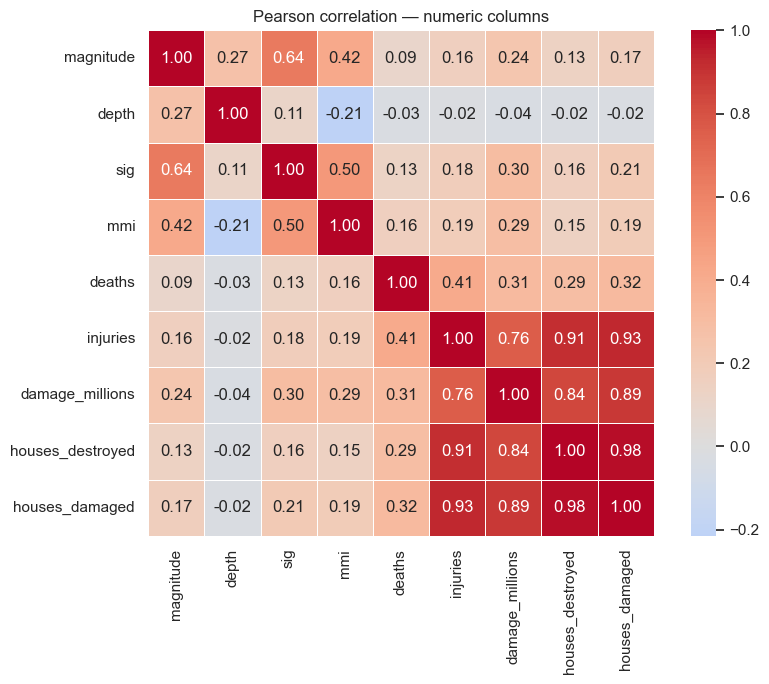

In [15]:
corr_cols = ['magnitude', 'depth', 'sig', 'mmi',
             'deaths', 'injuries', 'damage_millions',
             'houses_destroyed', 'houses_damaged']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation — numeric columns')
plt.tight_layout()
plt.show()

## 12. Rows where deaths > 0 but damage_millions is missing

In [16]:
if 'deaths' in df.columns and 'damage_millions' in df.columns:
    deadly_no_damage = df[(df['deaths'] > 0) & df['damage_millions'].isna()]
    print(f'Rows with deaths but no damage_millions: {len(deadly_no_damage)}')
    deadly_no_damage[['time', 'location_name', 'magnitude', 'deaths', 'damage_millions']].head(10)

Rows with deaths but no damage_millions: 384


## 13. Duplicate / near-duplicate check

In [17]:
# Exact duplicates
n_exact = df.duplicated().sum()
print(f'Exact duplicate rows: {n_exact}')

# Same usgs_id appearing more than once
if 'usgs_id' in df.columns:
    dup_ids = df[df.duplicated(subset='usgs_id', keep=False)]
    print(f'Rows sharing a usgs_id: {len(dup_ids)}')
    if len(dup_ids):
        display(dup_ids[['usgs_id', 'time', 'location_name', 'magnitude']].head(10))

# Same ncei_id appearing more than once
if 'ncei_id' in df.columns:
    dup_ncei = df[df.duplicated(subset='ncei_id', keep=False)]
    print(f'Rows sharing an ncei_id: {len(dup_ncei)}')

Exact duplicate rows: 0
Rows sharing a usgs_id: 0
Rows sharing an ncei_id: 0


## 14. Summary — things to consider cleaning

Run this cell last after reviewing the outputs above. Edit the list as you go.

In [18]:
issues = []

# Columns >50% missing
high_null = df.isna().mean()
drop_candidates = high_null[high_null > 0.5].index.tolist()
if drop_candidates:
    issues.append(f'Columns >50% null (consider dropping): {drop_candidates}')

# USGS placeholder depths
if 'depth' in df.columns:
    n_placeholder = df['depth'].isin([10.0, 33.0]).sum()
    issues.append(f'Rows with USGS placeholder depth (10 or 33 km): {n_placeholder} ({n_placeholder/len(df):.1%})')

# Missing time
if 'time' in df.columns:
    n_no_time = df['time'].isna().sum()
    if n_no_time:
        issues.append(f'Rows with no timestamp: {n_no_time}')

# Missing location
for col in ['latitude', 'longitude']:
    if col in df.columns:
        n = df[col].isna().sum()
        if n:
            issues.append(f'Rows with no {col}: {n}')

# Negative deaths / damage
for col in ['deaths', 'damage_millions', 'injuries']:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg:
            issues.append(f'Rows with negative {col}: {n_neg}')

print('=== Potential cleaning issues ===')
for i, issue in enumerate(issues, 1):
    print(f'{i}. {issue}')

if not issues:
    print('No obvious issues found!')

=== Potential cleaning issues ===
1. Columns >50% null (consider dropping): ['houses_damaged_total', 'houses_damaged_order_total', 'houses_destroyed', 'houses_destroyed_order', 'houses_damaged', 'houses_damaged_order', 'mag_surface_wave', 'houses_destroyed_total', 'houses_destroyed_order_total', 'deaths', 'deaths_order', 'damage_millions', 'mag_local', 'deaths_total', 'deaths_order_total', 'damage_millions_total', 'tsunami_event_id', 'intensity', 'volcano_event_id', 'area', 'missing', 'missing_order', 'missing_total', 'missing_order_total', 'mag_unkown', 'alert']
2. Rows with USGS placeholder depth (10 or 33 km): 375 (26.9%)
3. Rows with no timestamp: 43


## 15. Earthquakes with missing deaths — are they really 0?

`NaN` in the `deaths` column could mean truly zero deaths, or simply unreported data.
The cells below let you browse these rows and cross-check against magnitude, location,
and other impact columns to judge which is which.

In [19]:
missing_deaths = df[df['deaths'].isna()].copy()

print(f'Rows with missing deaths : {len(missing_deaths)} ({len(missing_deaths)/len(df):.1%})')
print(f'Rows with deaths = 0     : {(df["deaths"] == 0).sum()}')
print(f'Rows with deaths > 0     : {(df["deaths"] > 0).sum()}')

Rows with missing deaths : 831 (59.7%)
Rows with deaths = 0     : 0
Rows with deaths > 0     : 561


In [20]:
# Full list sorted by magnitude — highest magnitude at top (most likely to have had deaths)
cols_to_show = ['time', 'location_name', 'country', 'magnitude', 'depth',
                'deaths', 'injuries', 'damage_millions', 'houses_destroyed', 'sig', 'mmi']
cols_to_show = [c for c in cols_to_show if c in df.columns]

missing_deaths[cols_to_show].sort_values('magnitude', ascending=False)

,time,location_name,country,magnitude,depth,deaths,injuries,damage_millions,houses_destroyed,sig,mmi
362,2006-11-15 11:14:13.570000+00:00,RUSSIA: KURIL ISLANDS,RUSSIA,8.30,10.00,NaN,NaN,NaN,NaN,1064,6.90
774,2013-05-24 05:44:48.980000+00:00,RUSSIA: SEVERO KURILSKIYE,RUSSIA,8.30,598.10,NaN,NaN,NaN,NaN,1115,4.89
1046,2018-08-19 00:19:40.670000+00:00,FIJI ISLANDS,FIJI,8.20,600.00,NaN,NaN,NaN,NaN,1052,4.03
1205,2021-07-29 06:15:49.188000+00:00,ALASKA PENINSULA,USA,8.20,35.00,NaN,NaN,NaN,NaN,1499,7.36
711,2012-04-11 10:43:10.850000+00:00,INDONESIA: N SUMATRA: OFF WEST COAST,INDONESIA,8.20,25.10,NaN,NaN,NaN,NaN,1213,5.62
...,...,...,...,...,...,...,...,...,...,...,...
669,2011-02-17 22:47:21.530000+00:00,COLORADO: PAONIA,USA,3.10,1.00,NaN,NaN,NaN,NaN,148,NaN
568,NaT,AUSTRALIA: MORNINGTON,AUSTRALIA,3.10,0.00,NaN,NaN,NaN,NaN,148,4.81
664,NaT,OKLAHOMA: LUTHER,USA,2.50,5.30,NaN,NaN,NaN,NaN,96,NaN
184,2004-01-10 07:43:18.060000+00:00,SLOVAKIA: SLOVENSKO L'UPCA,SLOVAKIA,2.20,5.00,NaN,NaN,NaN,NaN,74,NaN


In [23]:
# High-suspicion rows: missing deaths BUT has injuries, damage, or destroyed houses
# These almost certainly are NOT zero deaths — the data is just missing
suspicious = missing_deaths[
    missing_deaths[['injuries', 'damage_millions', 'houses_destroyed']]
    .fillna(0).gt(0).any(axis=1)
]

print(f'Missing deaths but has injuries / damage / houses destroyed: {len(suspicious)}')
suspicious[cols_to_show].sort_values('magnitude', ascending=False)

Missing deaths but has injuries / damage / houses destroyed: 375


,time,location_name,country,magnitude,depth,deaths,injuries,damage_millions,houses_destroyed,sig,mmi
160,2003-09-25 19:50:06.360000+00:00,JAPAN: HOKKAIDO,JAPAN,8.16,27.00,NaN,849.00,90.00,NaN,1024,8.67
316,2006-05-03 15:26:40.290000+00:00,TONGA ISLANDS,TONGA,8.00,55.00,NaN,1.00,NaN,NaN,1013,6.52
104,2002-11-03 22:12:41.518000+00:00,"ALASKA: SLANA, MENTASTA LAKE, FAIRBANKS",USA,7.90,4.20,NaN,1.00,56.00,NaN,1750,8.58
867,2015-05-30 11:23:02.110000+00:00,JAPAN: BONIN ISLANDS [CHICHIJIMA ISLAND],JAPAN,7.80,664.00,NaN,12.00,NaN,NaN,1151,3.36
1148,2020-01-28 19:10:24.918000+00:00,CUBA: GRANMA; CAYMAN IS; JAMAICA,CUBA,7.70,14.86,NaN,NaN,90.00,1.00,1812,6.04
...,...,...,...,...,...,...,...,...,...,...,...
1368,2024-09-23 10:21:24.925000+00:00,PERU: AYACUCHO,PERU,4.20,34.30,NaN,NaN,NaN,5.00,272,NaN
48,2001-07-14 17:58:47.170000+00:00,CHINA: YUNNAN PROVINCE: JIANGCHUAN,CHINA,4.10,33.00,NaN,2.00,NaN,150.00,259,NaN
535,2009-03-26 04:44:11.650000+00:00,INDIA: CHAIBASA,INDIA,4.10,10.00,NaN,5.00,NaN,NaN,259,4.72
482,2008-06-06 21:16:33.880000+00:00,INDIA: MANPUR,INDIA,3.80,11.40,NaN,2.00,NaN,NaN,222,4.34


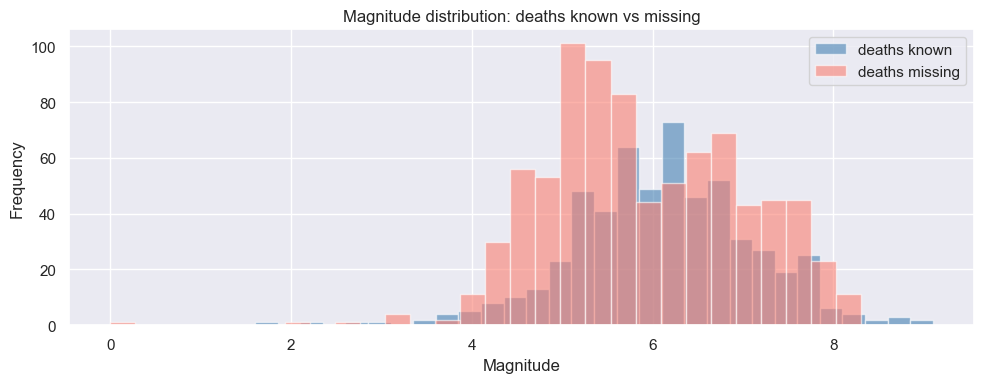

In [24]:
# Are missing-deaths rows just smaller earthquakes, or spread across all magnitudes?
fig, ax = plt.subplots(figsize=(10, 4))
df[df['deaths'].notna()]['magnitude'].plot(
    kind='hist', bins=30, alpha=0.6, label='deaths known', ax=ax, color='steelblue')
df[df['deaths'].isna()]['magnitude'].plot(
    kind='hist', bins=30, alpha=0.6, label='deaths missing', ax=ax, color='salmon')
ax.set_xlabel('Magnitude')
ax.set_title('Magnitude distribution: deaths known vs missing')
ax.legend()
plt.tight_layout()
plt.show()